In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("dynaprice_training_data.csv");

In [3]:
df.head()

,view_count,wishlist_add_count,cart_add_count,buy_count,price_change_pct
0,4,0,1,0,-1.00
1,3,0,0,0,-2.15
2,2,0,0,0,-2.46
3,11,1,1,0,1.87
4,41,4,6,6,4.89


In [4]:
df.isnull()

,view_count,wishlist_add_count,cart_add_count,buy_count,price_change_pct
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
14995,False,False,False,False,False
14996,False,False,False,False,False
14997,False,False,False,False,False
14998,False,False,False,False,False


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   view_count          15000 non-null  int64  
 1   wishlist_add_count  15000 non-null  int64  
 2   cart_add_count      15000 non-null  int64  
 3   buy_count           15000 non-null  int64  
 4   price_change_pct    15000 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 586.1 KB


In [6]:
df.describe()

,view_count,wishlist_add_count,cart_add_count,buy_count,price_change_pct
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,13.480867,1.755667,1.383667,0.398600,1.134432
std,14.793957,2.355123,2.010125,0.802264,3.011771
min,0.000000,0.000000,0.000000,0.000000,-3.360000
25%,3.000000,0.000000,0.000000,0.000000,-1.870000
50%,7.000000,1.000000,1.000000,0.000000,0.700000
75%,17.000000,3.000000,2.000000,1.000000,4.260000
max,70.000000,15.000000,14.000000,8.000000,5.000000


In [7]:
import matplotlib.pyplot as plt

In [8]:
X = df.iloc[:, :-1]   # all rows, all columns except the last
Y = df.iloc[:, -1]    # all rows, just the last column

In [9]:
X

,view_count,wishlist_add_count,cart_add_count,buy_count
0,4,0,1,0
1,3,0,0,0
2,2,0,0,0
3,11,1,1,0
4,41,4,6,6
...,...,...,...,...
14995,12,1,4,0
14996,42,9,4,0
14997,14,0,2,1
14998,0,1,1,0


In [10]:
Y

0       -1.00
1       -2.15
2       -2.46
3        1.87
4        4.89
         ... 
14995    3.95
14996    5.00
14997    3.56
14998   -1.47
14999   -2.01
Name: price_change_pct, Length: 15000, dtype: float64

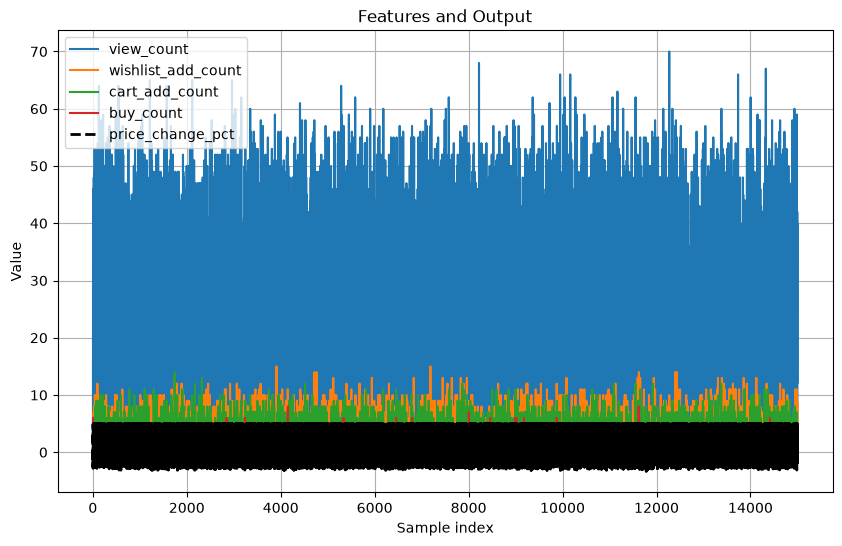

In [11]:
plt.figure(figsize=(10, 6))

# plot each input feature
for i, col in enumerate(X.columns):
    plt.plot(X[col], label=col)

# plot the output on top, in a distinct style
plt.plot(Y, label=Y.name if hasattr(Y, 'name') else 'Y', color='black', linewidth=2, linestyle='--')

plt.xlabel("Sample index")
plt.ylabel("Value")
plt.title("Features and Output")
plt.legend()
plt.grid(True)
plt.show()

## Model training: baseline vs. gradient boosting

We're predicting `price_change_pct` (a number, e.g. `+3.2` meaning "raise price 3.2%") from the four interest signals. Two models, so we have something to compare:

- **Linear Regression (baseline)** — fits a straight-line relationship: "each extra view/cart-add/etc. moves price by a fixed amount." Fast, interpretable, but can't capture things like "views only start mattering once wishlist activity is also high."
- **Gradient Boosting Regressor (stronger model)** — think of it like a team of interns each fixing the previous intern's mistakes: it builds a small decision tree, checks where it was wrong, builds another tree to correct those specific errors, and repeats. This lets it pick up non-linear interactions between the four signals that a straight line can't.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((12000, 4), (3000, 4))

### Baseline: Linear Regression

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

lr_pred = lr_model.predict(X_test)
lr_mae = mean_absolute_error(Y_test, lr_pred)
lr_rmse = mean_squared_error(Y_test, lr_pred) ** 0.5
lr_r2 = r2_score(Y_test, lr_pred)

print(f"Linear Regression -> MAE: {lr_mae:.4f}, RMSE: {lr_rmse:.4f}, R2: {lr_r2:.4f}")

Linear Regression -> MAE: 1.5679, RMSE: 1.7468, R2: 0.6651


### Stronger model: Gradient Boosting Regressor

In [15]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, Y_train)

gb_pred = gb_model.predict(X_test)
gb_mae = mean_absolute_error(Y_test, gb_pred)
gb_rmse = mean_squared_error(Y_test, gb_pred) ** 0.5
gb_r2 = r2_score(Y_test, gb_pred)

print(f"Gradient Boosting  -> MAE: {gb_mae:.4f}, RMSE: {gb_rmse:.4f}, R2: {gb_r2:.4f}")

Gradient Boosting  -> MAE: 0.1250, RMSE: 0.1601, R2: 0.9972


### Comparison

**MAE** (mean absolute error) — on average, how far off is a prediction, in percentage points of price change. Easy to explain in an interview: "our model is off by about X% on average."

**RMSE** (root mean squared error) — same units as MAE, but squares errors before averaging, so a few big mistakes hurt this number more than MAE. Lower is better for both.

In [16]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Gradient Boosting"],
    "MAE": [lr_mae, gb_mae],
    "RMSE": [lr_rmse, gb_rmse],
    "R2": [lr_r2, gb_r2],
})
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,1.567933,1.746807,0.665144
1,Gradient Boosting,0.125024,0.160108,0.997187


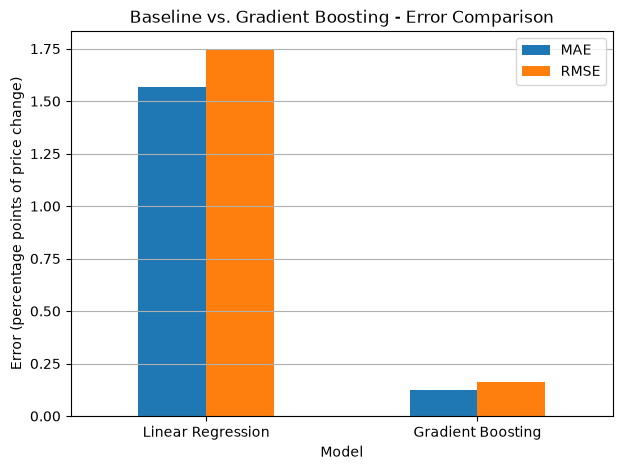

In [17]:
comparison.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(7, 5))
plt.ylabel("Error (percentage points of price change)")
plt.title("Baseline vs. Gradient Boosting - Error Comparison")
plt.xticks(rotation=0)
plt.grid(True, axis="y")
plt.show()

In [18]:
# Pick the model with the lower RMSE (penalizes bad misses more, which matters
# for a pricing engine - we care more about avoiding a few wild price swings
# than shaving a tiny bit off the average error).
if gb_rmse < lr_rmse:
    chosen_name, chosen_model = "gradient_boosting", gb_model
else:
    chosen_name, chosen_model = "linear_regression", lr_model

print(f"Recommended model: {chosen_name}")
print(f"  Linear Regression -> MAE {lr_mae:.4f} / RMSE {lr_rmse:.4f}")
print(f"  Gradient Boosting  -> MAE {gb_mae:.4f} / RMSE {gb_rmse:.4f}")

Recommended model: gradient_boosting
  Linear Regression -> MAE 1.5679 / RMSE 1.7468
  Gradient Boosting  -> MAE 0.1250 / RMSE 0.1601


**Why this pick, for the interview answer:** Gradient Boosting should win here because real interest signals rarely combine in a straight line - e.g. a view spike probably only means something once wishlist/cart activity also picks up, and boosting can learn that kind of "only matters in combination" pattern where linear regression is stuck assuming every feature contributes independently. The trade-off: boosting is slower to train, less interpretable (no single coefficient per feature), and needs the guardrail/clamping logic (±5% bound) enforced in the serving code, not the model itself, since nothing stops it predicting outside that range on unseen data.

In [20]:
joblib.dump(chosen_model, "dynaprice_model.joblib")
joblib.dump(list(X.columns), "dynaprice_model_features.joblib")  # column order, needed at inference time
print(f"Saved {chosen_name} to dynaprice_model.joblib")

Saved gradient_boosting to dynaprice_model.joblib


**Loading this in FastAPI later:**
```python
import joblib
model = joblib.load("dynaprice_model.joblib")
feature_order = joblib.load("dynaprice_model_features.joblib")
# build the input row in feature_order, then model.predict([[...]])
```